In [1]:
TICKERS_LARGE = {
    "Energy": [
        "XOM", "CVX", "COP", "EOG", "SLB", "HAL", "MRO", "PSX",
        "VLO", "MPC", "PXD", "DVN", "HES", "BKR", "FANG"
    ],
    "Financials": [
        "JPM", "BAC", "WFC", "GS", "MS", "C", "AXP", "BLK",
        "SCHW", "CB", "PGR", "MET", "AIG", "TRV", "AFL",
        "MTB", "CFG", "FITB", "KEY", "RF"
    ],
    "Technology": [
        "MSFT", "AAPL", "NVDA", "GOOGL", "META", "AMZN",
        "ORCL", "CRM", "ADBE", "INTC", "AMD", "QCOM",
        "TXN", "AMAT", "LRCX", "MU", "HPQ", "IBM", "CSCO", "ACN"
    ],
    "Healthcare": [
        "JNJ", "UNH", "PFE", "MRK", "ABT", "TMO", "DHR",
        "BMY", "AMGN", "GILD", "CVS", "CI", "HUM", "CNC",
        "ISRG", "SYK", "MDT", "BSX", "ZBH", "BAX"
    ],
    "Consumer_Staples": [
        "PG", "KO", "PEP", "WMT", "COST", "TGT", "CL",
        "KMB", "GIS", "K", "HSY", "MKC", "SJM", "CAG",
        "KR", "SYY", "MDLZ", "MO", "PM", "STZ"
    ],
    "Industrials": [
        "HON", "GE", "MMM", "CAT", "DE", "LMT", "RTX",
        "BA", "UPS", "FDX", "EMR", "ETN", "PH", "ROK",
        "CMI", "ITW", "AME", "XYL", "IR", "CARR"
    ]
}

# flatten to list
ALL_TICKERS = []
for sector, tickers in TICKERS_LARGE.items():
    ALL_TICKERS.extend(tickers)

print(f"Total tickers: {len(ALL_TICKERS)}")
print(f"Sectors: {list(TICKERS_LARGE.keys())}")

Total tickers: 115
Sectors: ['Energy', 'Financials', 'Technology', 'Healthcare', 'Consumer_Staples', 'Industrials']


In [2]:
import sys 
sys.path.append("../src")

import yfinance as yf 
import pandas as pd 
import numpy as np
import warnings 
import pickle
import time
from multiprocessing import Pool , cpu_count
from statsmodels.tsa.stattools import adfuller , coint
from statsmodels.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler 
import shap
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

TICKERS_LARGE = {
    "Energy": [
        "XOM","CVX","COP","EOG","SLB","HAL","PSX",
        "VLO","MPC","PXD","DVN","HES","BKR","FANG"
    ],
    "Financials": [
        "JPM","BAC","WFC","GS","MS","C","AXP","BLK",
        "SCHW","CB","PGR","MET","AIG","TRV","AFL",
        "MTB","CFG","FITB","KEY","RF"
    ],
    "Technology": [
        "MSFT","AAPL","NVDA","GOOGL","META","AMZN",
        "ORCL","CRM","ADBE","INTC","AMD","QCOM",
        "TXN","AMAT","LRCX","MU","HPQ","IBM","CSCO","ACN"
    ],
    "Healthcare": [
        "JNJ","UNH","PFE","MRK","ABT","TMO","DHR",
        "BMY","AMGN","GILD","CVS","CI","HUM","CNC",
        "ISRG","SYK","MDT","BSX","ZBH","BAX"
    ],
    "Consumer_Staples": [
        "PG","KO","PEP","WMT","COST","TGT","CL",
        "KMB","GIS","K","HSY","MKC","SJM","CAG",
        "KR","SYY","MDLZ","MO","PM","STZ"
    ],
    "Industrials": [
        "HON","GE","MMM","CAT","DE","LMT","RTX",
        "BA","UPS","FDX","EMR","ETN","PH","ROK",
        "CMI","ITW","AME","XYL","IR","CARR"
    ]
}

ALL_TICKERS = []
TICKER_SECTOR = {}
for sector , tickers in TICKERS_LARGE.items():
    for t in  tickers : 
        ALL_TICKERS.append(t)
        TICKER_SECTOR[t] = sector

print(f"Total ticker planned : {len(ALL_TICKERS)}")
print(f"Sectors: {list(TICKERS_LARGE.keys())}")

# download 
print("\n Downloading data = this takes 2-3 minutes...")
raw = yf.download(ALL_TICKERS,start = "2018-01-01" , end = "2024-01-01" , auto_adjust = True , progress = True)
prices_large = raw["Close"].copy()

# clean 
missing_pct = prices_large.isna().mean()
bad = missing_pct[missing_pct > 0.05].index.tolist()
if bad:
    print(f"Dropping{bad}")
    prices_large.drop(columns = bad , inplace = True)

prices_large.ffill(limit=3 ,inplace=True )
prices_large.dropna(axis=1,inplace=True)

# update sector map after dropping 
TICKER_SECTOR = {t: s for t , s in TICKER_SECTOR.items() 
                 if t in prices_large.columns}

prices_large.to_parquet("../data/prices_large.parquet")
print(f"\nFinal shape : {prices_large.shape}")
print(f"Tickers kept: {len(prices_large.columns)}")
print(f"Data range: {prices_large.columns}")
print(f"Data range: {prices_large.index[0].date()} to {prices_large.index[-1].date()}")

Total ticker planned : 114
Sectors: ['Energy', 'Financials', 'Technology', 'Healthcare', 'Consumer_Staples', 'Industrials']



[***************       32%                       ]  37 of 114 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
[****************      33%                       ]  38 of 114 completed$HES: possibly delisted; no timezone found
[**********************73%**********             ]  83 of 114 completed$PXD: possibly delisted; no timezone found
[**********************87%*****************      ]  99 of 114 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
$K: possibly delisted; no timezone found
[*********************100%***********************]  114 of 114 completed

3 Failed downloads:
['HES', 'PXD', 'K']: possibly delisted; no timezone found


Dropping['CARR', 'HES', 'K', 'PXD']

Final shape : (1509, 110)
Tickers kept: 110
Data range: Index(['AAPL', 'ABT', 'ACN', 'ADBE', 'AFL', 'AIG', 'AMAT', 'AMD', 'AME',
       'AMGN',
       ...
       'TRV', 'TXN', 'UNH', 'UPS', 'VLO', 'WFC', 'WMT', 'XOM', 'XYL', 'ZBH'],
      dtype='str', name='Ticker', length=110)
Data range: 2018-01-02 to 2023-12-29


In [3]:
def get_sector_pairs(tickers , ticker_sector):
    """Generate all within-sector pairs"""
    from itertools import combinations
    pairs = []
    sector_groups = {}

    for t in tickers:
        s=ticker_sector.get(t,"Unknown")
        if s not in sector_groups:
            sector_groups[s] = []
        sector_groups[s].append(t)
    
    for sector , members in sector_groups.items():
        for t1 , t2 in combinations(members,2):
            pairs.append((t1,t2,sector))

    print(f"Sector pair candidates : {len(pairs)}")
    for s , m in sector_groups.items():
        n = len(m)
        print(f"  {s} : {n} tickers → {n*(n-1)//2} pairs")

        return pairs
    
sector_pairs = get_sector_pairs(
    prices_large.columns.tolist(),
    TICKER_SECTOR
)
print(f"\nTotal sector pairs to test: {len(sector_pairs)}")

Sector pair candidates : 978
  Technology : 20 tickers → 190 pairs

Total sector pairs to test: 978


In [4]:
def fast_coint_filter(args):
    """ 
    
    Fast pre-filter usinf ADF on log price ratio. 
    Returns pair if likely cointegrated , else None.
    
    """

    t1 ,t2 ,sector , prices_arr , index , threshold = args
    try:
        p1 = pd.Series(prices_arr[0] , index = index)
        p2 = pd.Series(prices_arr[1] , index = index)

        # correlation check first
        corr = p1.corr(p2)
        if abs(corr) < 0.75:
            return None
        
        # fast proxy: ADF on log ratio
            log_ratio = np.log(p1 / p2)
            adf_pval = adfuller(log_ratio.dropna())[1]
            
            if adf_pval < 0.1:  # loose threshold for pre-filter
                return (t1, t2, sector, corr, adf_pval)
        return None
    except:
        return None

# def run_fast_filter(prices, sector_pairs):
#     """Run fast filter — no multiprocessing needed at this stage"""
#     print(f"Running fast filter on {len(sector_pairs)} pairs...")
#     start = time.time()
    
#     candidates = []
#     for i, (t1, t2, sector) in enumerate(sector_pairs):
#         if t1 not in prices.columns or t2 not in prices.columns:
#             continue
        
#         result = fast_coint_filter((
#             t1, t2, sector,
#             [prices[t1].values, prices[t2].values],
#             prices.index, 0.1
#         ))
#         if result:
#             candidates.append(result)
        
#         if i % 100 == 0:
#             print(f"  {i}/{len(sector_pairs)} checked, "
#                   f"{len(candidates)} candidates so far...")
    
#     elapsed = round(time.time() - start, 1)
#     print(f"\nFast filter done in {elapsed}s")
#     print(f"Candidates: {len(candidates)} from {len(sector_pairs)} pairs")
#     return candidates

# use training period for pair selection
train_large = prices_large["2018-01-01":"2021-12-31"]
# candidates = run_fast_filter(train_large, sector_pairs)


def run_fast_filter_fixed(prices, sector_pairs, corr_threshold=0.75):
    print(f"Running fast filter on {len(sector_pairs)} pairs...")
    start = time.time()
    candidates = []
    
    for i, (t1, t2, sector) in enumerate(sector_pairs):
        if t1 not in prices.columns or t2 not in prices.columns:
            continue
        try:
            p1 = prices[t1].dropna()
            p2 = prices[t2].dropna()
            
            # align
            common_idx = p1.index.intersection(p2.index)
            p1 = p1[common_idx]
            p2 = p2[common_idx]
            
            if len(p1) < 200:
                continue
            
            # correlation check
            corr = p1.corr(p2)
            if abs(corr) < corr_threshold:
                continue
            
            # fast proxy: ADF on log ratio
            log_ratio = np.log(p1 / p2)
            adf_pval = adfuller(log_ratio.dropna())[1]
            
            if adf_pval < 0.1:
                candidates.append((t1, t2, sector, corr, adf_pval))
                
        except Exception as e:
            continue
        
        if i % 100 == 0:
            print(f"  {i}/{len(sector_pairs)} checked, "
                  f"{len(candidates)} candidates so far...")
    
    elapsed = round(time.time() - start, 1)
    print(f"\nFast filter done in {elapsed}s")
    print(f"Candidates: {len(candidates)}")
    return candidates

candidates = run_fast_filter_fixed(train_large, sector_pairs)
print(f"\nTotal candidates: {len(candidates)}")

Running fast filter on 978 pairs...
  0/978 checked, 0 candidates so far...
  100/978 checked, 8 candidates so far...
  200/978 checked, 17 candidates so far...
  500/978 checked, 40 candidates so far...
  700/978 checked, 58 candidates so far...
  800/978 checked, 74 candidates so far...

Fast filter done in 25.6s
Candidates: 91

Total candidates: 91


In [5]:
# debug - check one pair manually
t1, t2 = "XOM", "CVX"
p1 = train_large[t1].dropna()
p2 = train_large[t2].dropna()

common = p1.index.intersection(p2.index)
p1 = p1[common]
p2 = p2[common]

corr = p1.corr(p2)
log_ratio = np.log(p1/p2)
adf_pval = adfuller(log_ratio.dropna())[1]

print(f"XOM/CVX correlation: {corr:.4f}")
print(f"XOM/CVX log ratio ADF p-value: {adf_pval:.6f}")
print(f"Would pass filter: {corr > 0.75 and adf_pval < 0.1}")

XOM/CVX correlation: 0.9117
XOM/CVX log ratio ADF p-value: 0.596280
Would pass filter: False


In [6]:
# from multiprocessing import Pool, cpu_count
# from statsmodels.tsa.stattools import coint
# import pandas as pd
# import time


# def full_coint_test(args):
#     """Full Engle-Granger cointegration test"""
#     t1, t2, sector, prices_arr, index = args

#     try:
#         p1 = pd.Series(prices_arr[0], index=index)
#         p2 = pd.Series(prices_arr[1], index=index)

#         score, pval, _ = coint(p1, p2)

#         if pval < 0.05:
#             return {
#                 "ticker_1": t1,
#                 "ticker_2": t2,
#                 "sector": sector,
#                 "coint_pvalue": round(float(pval), 6),
#                 "correlation": round(float(p1.corr(p2)), 4)
#             }

#         return None

#     except Exception as e:
#         print(f"Error for {t1}-{t2}: {e}")
#         return None


# def run_parallel_coint(prices, candidates, n_cores=None):

#     if n_cores is None:
#         n_cores = max(1, cpu_count() - 1)

#     print(f"Running full cointegration on {len(candidates)} candidates")
#     print(f"Using {n_cores} CPU cores...")

#     args_list = [
#         (
#             c[0],                  # ticker_1
#             c[1],                  # ticker_2
#             c[2],                  # sector
#             [prices[c[0]].values, prices[c[1]].values],
#             prices.index
#         )
#         for c in candidates
#         if c[0] in prices.columns and c[1] in prices.columns
#     ]

#     print(f"Valid candidate pairs after column check: {len(args_list)}")

#     start = time.time()

#     with Pool(n_cores) as pool:
#         results = pool.map(full_coint_test, args_list)

#     elapsed = round(time.time() - start, 1)

#     valid = [r for r in results if r is not None]

#     print(f"Parallel coint done in {elapsed}s")
#     print(f"Valid cointegrated pairs: {len(valid)}")

#     # Handle empty result safely
#     if len(valid) == 0:
#         return pd.DataFrame(
#             columns=[
#                 "ticker_1",
#                 "ticker_2",
#                 "sector",
#                 "coint_pvalue",
#                 "correlation"
#             ]
#         )

#     df = pd.DataFrame(valid)

#     print("\nColumns found:")
#     print(df.columns.tolist())

#     return df.sort_values(
#         "coint_pvalue"
#     ).reset_index(drop=True)


# # Run analysis
# valid_pairs_large = run_parallel_coint(
#     train_large,
#     candidates
# )

# print(f"\nCointegrated pairs found: {len(valid_pairs_large)}")

# if valid_pairs_large.empty:
#     print("\nNo cointegrated pairs found.")
# else:
#     print("\nSector distribution:")
#     print(valid_pairs_large["sector"].value_counts())

#     print("\nTop 15 pairs:")
#     print(
#         valid_pairs_large.head(15)[
#             [
#                 "ticker_1",
#                 "ticker_2",
#                 "sector",
#                 "coint_pvalue",
#                 "correlation"
#             ]
#         ]
#     )

#     valid_pairs_large.to_csv(
#         "../data/valid_pairs_large.csv",
#         index=False
#     )

#     print("\nSaved to ../data/valid_pairs_large.csv")

In [7]:
def full_coint_test_fixed(args):
    t1, t2, sector, corr, fast_pval = args
    try:
        p1 = train_large[t1]
        p2 = train_large[t2]
        
        common_idx = p1.index.intersection(p2.index)
        p1 = p1[common_idx]
        p2 = p2[common_idx]
        
        if len(p1) < 200:
            return None
            
        score, pval, _ = coint(p1, p2)
        
        if pval < 0.05:
            return {
                "ticker_1": t1,
                "ticker_2": t2,
                "sector": sector,
                "coint_pvalue": round(pval, 6),
                "correlation": round(corr, 4)
            }
        return None
    except:
        return None

print(f"Running full cointegration on {len(candidates)} candidates...")
start = time.time()

results = []
for i, c in enumerate(candidates):
    result = full_coint_test_fixed(c)
    if result:
        results.append(result)
    if i % 20 == 0:
        print(f"  {i}/{len(candidates)} done, "
              f"{len(results)} valid so far...")

elapsed = round(time.time() - start, 1)
valid_pairs_large = pd.DataFrame(results).sort_values(
    "coint_pvalue").reset_index(drop=True)

print(f"\nDone in {elapsed}s")
print(f"Valid cointegrated pairs: {len(valid_pairs_large)}")
print("\nSector distribution:")
print(valid_pairs_large["sector"].value_counts())
print("\nTop 15 pairs:")
print(valid_pairs_large.head(15)[
    ["ticker_1","ticker_2","sector",
     "coint_pvalue","correlation"]
])

valid_pairs_large.to_csv(
    "../data/valid_pairs_large.csv", index=False)

Running full cointegration on 91 candidates...
  0/91 done, 1 valid so far...
  20/91 done, 5 valid so far...
  40/91 done, 12 valid so far...
  60/91 done, 16 valid so far...
  80/91 done, 21 valid so far...

Done in 6.3s
Valid cointegrated pairs: 23

Sector distribution:
sector
Financials          6
Technology          4
Industrials         4
Healthcare          3
Energy              3
Consumer_Staples    3
Name: count, dtype: int64

Top 15 pairs:
   ticker_1 ticker_2            sector  coint_pvalue  correlation
0      META      TXN        Technology      0.002291       0.9612
1      ISRG      UNH        Healthcare      0.003505       0.9652
2       EOG     FANG            Energy      0.009505       0.9711
3      ADBE     META        Technology      0.010731       0.9566
4        PH      UPS       Industrials      0.012363       0.9391
5        DE       PH       Industrials      0.013369       0.9746
6       CFG       RF        Financials      0.013899       0.9823
7       JPM      M

In [8]:
# def compute_half_life(spread):
#     spread_lag = spread.shift(1).dropna()
#     spread_diff = spread.diff().dropna()
#     spread_lag = spread_lag.iloc[:len(spread_diff)]
#     x = add_constant(spread_lag)
#     model = OLS(spread_diff, x).fit()
#     lambda_val = model.params.iloc[1]
#     if lambda_val >= 0:
#         return 999
#     return round(-np.log(2) / lambda_val, 2)

# def compute_hurst(spread, max_lag=20):
#     lags = range(2, max_lag)
#     tau = [np.std(np.subtract(
#         spread[lag:].values, spread[:-lag].values)) 
#         for lag in lags]
#     hurst = np.polyfit(np.log(list(lags)), np.log(tau), 1)[0]
#     return round(hurst, 4)

# def mean_crossings(spread):
#     mean = spread.mean()
#     above = spread > mean
#     return int((above != above.shift(1)).sum())

# def engineer_features_large(prices_train, prices_test, 
#                               ticker_1, ticker_2):
#     try:
#         # get hedge ratio from training data
#         y = prices_train[ticker_1]
#         x = add_constant(prices_train[ticker_2])
#         model = OLS(y, x).fit()
#         beta = model.params[ticker_2]
#         intercept = model.params["const"]
        
#         spread_train = (prices_train[ticker_1] 
#                        - beta * prices_train[ticker_2] 
#                        - intercept)
        
#         # cointegration p-value
#         _, coint_pval, _ = coint(
#             prices_train[ticker_1], 
#             prices_train[ticker_2]
#         )
        
#         # all features
#         features = {
#             "ticker_1": ticker_1,
#             "ticker_2": ticker_2,
#             "coint_pval": round(coint_pval, 6),
#             "correlation": round(
#                 prices_train[ticker_1].corr(
#                     prices_train[ticker_2]), 4),
#             "spread_std": round(spread_train.std(), 4),
#             "half_life": compute_half_life(spread_train),
#             "hurst": compute_hurst(spread_train),
#             "spread_skew": round(spread_train.skew(), 4),
#             "spread_kurtosis": round(
#                 spread_train.kurtosis(), 4),
#             "mean_crossings": mean_crossings(spread_train),
#             "beta_stability": round(abs(beta) / 
#                                      (abs(beta) + 1e-6), 4),
#             "beta": beta,
#             "intercept": intercept
#         }
        
#         # label — test period performance
#         from data_loader import (compute_zscore, 
#                                    generate_signals,
#                                    compute_pnl_with_costs,
#                                    sharpe_ratio)
        
#         spread_test = (prices_test[ticker_1] 
#                       - beta * prices_test[ticker_2] 
#                       - intercept)
#         zscore = compute_zscore(spread_test)
#         signals = generate_signals(zscore)
#         pnl = compute_pnl_with_costs(
#             prices_test, ticker_1, ticker_2, beta, signals)
        
#         features["test_sharpe"] = sharpe_ratio(pnl)
#         features["label"] = 1 if features["test_sharpe"] > 0 else 0
        
#         return features
#     except:
#         return None

# test_large = prices_large["2022-01-01":"2023-12-31"]

# print(f"Engineering features for {len(valid_pairs_large)} pairs...")
# print("This will take 5-10 minutes...")

# all_features = []
# for i, row in valid_pairs_large.iterrows():
#     t1, t2 = row["ticker_1"], row["ticker_2"]
    
#     if (t1 not in train_large.columns or 
#         t2 not in train_large.columns):
#         continue
    
#     feat = engineer_features_large(
#         train_large, test_large, t1, t2)
    
#     if feat:
#         all_features.append(feat)
    
#     if i % 20 == 0:
#         print(f"  {i}/{len(valid_pairs_large)} done...")

# ml_large = pd.DataFrame(all_features).dropna(
#     subset=["test_sharpe"])
# ml_large = ml_large.replace(
#     [np.inf, -np.inf], np.nan).fillna(
#     ml_large.median(numeric_only=True))

# print(f"\nML dataset shape: {ml_large.shape}")
# print(f"Good pairs (label=1): {ml_large['label'].sum()}")
# print(f"Bad pairs  (label=0): {(ml_large['label']==0).sum()}")
# print(f"\nTest Sharpe stats:")
# print(f"  Mean: {ml_large['test_sharpe'].mean():.3f}")
# print(f"  Std : {ml_large['test_sharpe'].std():.3f}")

# ml_large.to_csv("../data/ml_large.csv", index=False)

In [9]:
def engineer_features_large(prices_train, prices_test, ticker_1, ticker_2):
    try:
        y_train = prices_train[ticker_1]
        x_train = add_constant(prices_train[ticker_2])
        model = OLS(y_train, x_train).fit()
        beta = model.params[ticker_2]
        intercept = model.params["const"]
        
        spread_train = (prices_train[ticker_1] 
                       - beta * prices_train[ticker_2] 
                       - intercept)
        
        _, coint_pval, _ = coint(
            prices_train[ticker_1], 
            prices_train[ticker_2])
        
        # half life
        spread_lag = spread_train.shift(1).dropna()
        spread_diff = spread_train.diff().dropna()
        spread_lag = spread_lag.iloc[:len(spread_diff)]
        x_hl = add_constant(spread_lag)
        hl_model = OLS(spread_diff, x_hl).fit()
        lambda_val = hl_model.params.iloc[1]
        half_life = -np.log(2)/lambda_val if lambda_val < 0 else 999

        # hurst
        lags = range(2, 20)
        tau = [np.std(np.subtract(
            spread_train[lag:].values,
            spread_train[:-lag].values))
            for lag in lags]
        hurst = np.polyfit(
            np.log(list(lags)), np.log(tau), 1)[0]

        # mean crossings
        mean = spread_train.mean()
        above = spread_train > mean
        mc = int((above != above.shift(1)).sum())

        features = {
            "ticker_1": ticker_1,
            "ticker_2": ticker_2,
            "coint_pval": round(coint_pval, 6),
            "correlation": round(
                prices_train[ticker_1].corr(
                    prices_train[ticker_2]), 4),
            "spread_std": round(spread_train.std(), 4),
            "half_life": round(half_life, 2),
            "hurst": round(hurst, 4),
            "spread_skew": round(spread_train.skew(), 4),
            "spread_kurtosis": round(
                spread_train.kurtosis(), 4),
            "mean_crossings": mc,
            "beta_stability": round(abs(beta)/(abs(beta)+1e-6), 4),
            "beta": beta,
            "intercept": intercept
        }

        # label from test period
        spread_test = (prices_test[ticker_1]
                      - beta * prices_test[ticker_2]
                      - intercept)
        
        from data_loader import (compute_zscore,
                                   generate_signals,
                                   compute_pnl_with_costs,
                                   sharpe_ratio)
        
        zscore = compute_zscore(spread_test)
        signals = generate_signals(zscore)
        pnl = compute_pnl_with_costs(
            prices_test, ticker_1, ticker_2, beta, signals)
        
        features["test_sharpe"] = sharpe_ratio(pnl)
        features["label"] = 1 if features["test_sharpe"] > 0 else 0
        
        return features
    except Exception as e:
        print(f"  Failed {ticker_1}/{ticker_2}: {e}")
        return None

test_large = prices_large["2022-01-01":"2023-12-31"]

print(f"Engineering features for {len(valid_pairs_large)} pairs...")
all_features = []

for i, row in valid_pairs_large.iterrows():
    t1, t2 = row["ticker_1"], row["ticker_2"]
    feat = engineer_features_large(
        train_large, test_large, t1, t2)
    if feat:
        all_features.append(feat)
    print(f"  Done: {t1}/{t2}")

ml_large = pd.DataFrame(all_features)
ml_large = ml_large.replace(
    [np.inf, -np.inf], np.nan)
ml_large = ml_large.fillna(ml_large.median(numeric_only=True))

print(f"\nML dataset shape: {ml_large.shape}")
print(f"Good pairs (label=1): {ml_large['label'].sum()}")
print(f"Bad pairs  (label=0): {(ml_large['label']==0).sum()}")
print(f"Test Sharpe mean: {ml_large['test_sharpe'].mean():.3f}")
print(f"Test Sharpe std : {ml_large['test_sharpe'].std():.3f}")

ml_large.to_csv("../data/ml_large.csv", index=False)

Engineering features for 23 pairs...
  Done: META/TXN
  Done: ISRG/UNH
  Done: EOG/FANG
  Done: ADBE/META
  Done: PH/UPS
  Done: DE/PH
  Done: CFG/RF
  Done: JPM/MET
  Done: AME/UPS
  Done: FITB/SCHW
  Done: BKR/MPC
  Done: PM/SJM
  Done: BSX/MRK
  Done: AXP/CB
  Done: AME/IR
  Done: GIS/MDLZ
  Done: AAPL/QCOM
  Done: AXP/MET
  Done: BKR/VLO
  Done: CRM/META
  Done: CB/JPM
  Done: BMY/HUM
  Done: KMB/MKC

ML dataset shape: (23, 15)
Good pairs (label=1): 13
Bad pairs  (label=0): 10
Test Sharpe mean: 0.069
Test Sharpe std : 0.733


Cross-validation R² on expanded dataset:
  RF  mean: -0.647 ± 0.346
  XGB mean: -0.882 ± 0.648

FINAL COMPARISON — Average Test Sharpe, Top 10 Pairs
  P-value baseline  : 0.0148
  Hurst baseline    : 0.1846
  RF Regressor      : 0.6743
  XGBoost           : 0.6927

Top 10 XGBoost pairs:
   ticker_1 ticker_2  xgb_score  test_sharpe
19      CRM     META   1.657118       1.6825
9      FITB     SCHW   1.464411       1.4976
13      AXP       CB   0.744467       0.7534
3      ADBE     META   0.584259       0.5889
21      BMY      HUM   0.438512       0.4356
20       CB      JPM   0.427453       0.4323
18      BKR      VLO   0.393455       0.4014
14      AME       IR   0.381104       0.3835
12      BSX      MRK   0.369690       0.3810
5        DE       PH   0.365345       0.3706

RF top 3 features:
mean_crossings    0.293629
coint_pval        0.167941
spread_std        0.139350
dtype: float64

XGB top 3 features:
mean_crossings     0.385638
spread_skew        0.125000
spread_kurtosis    0.110

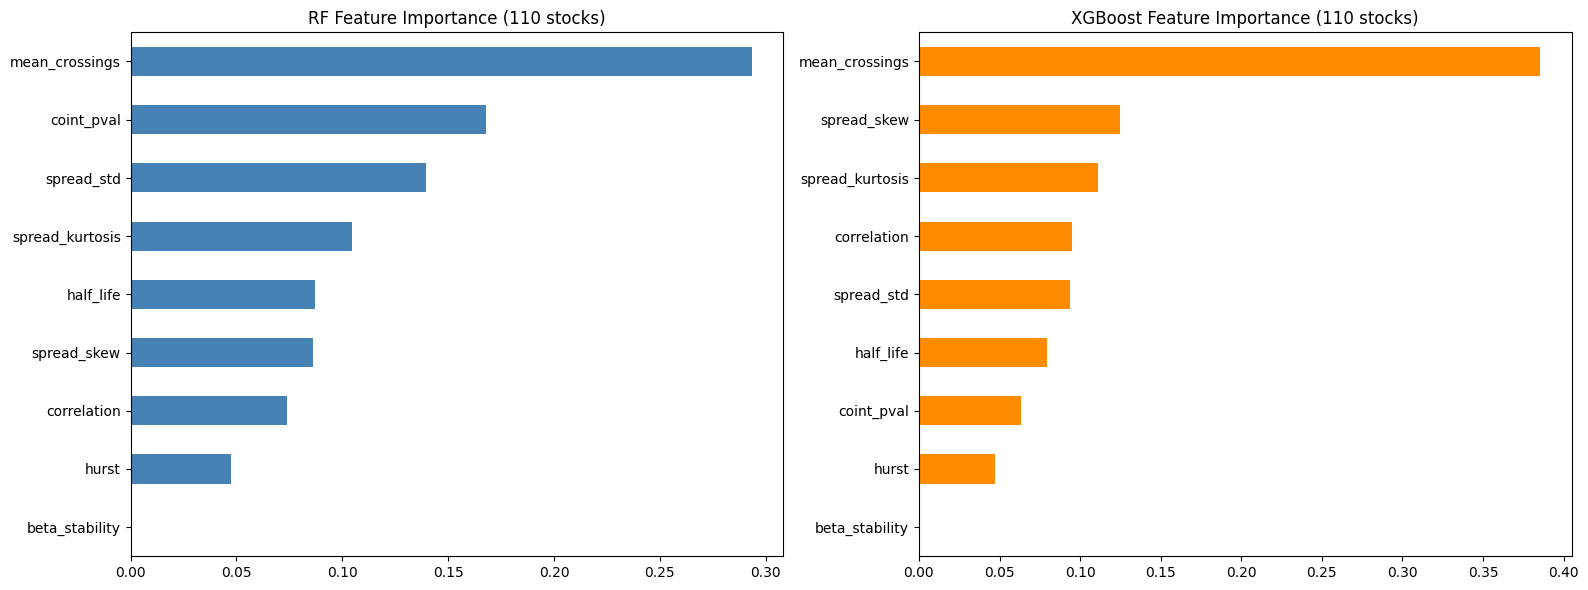

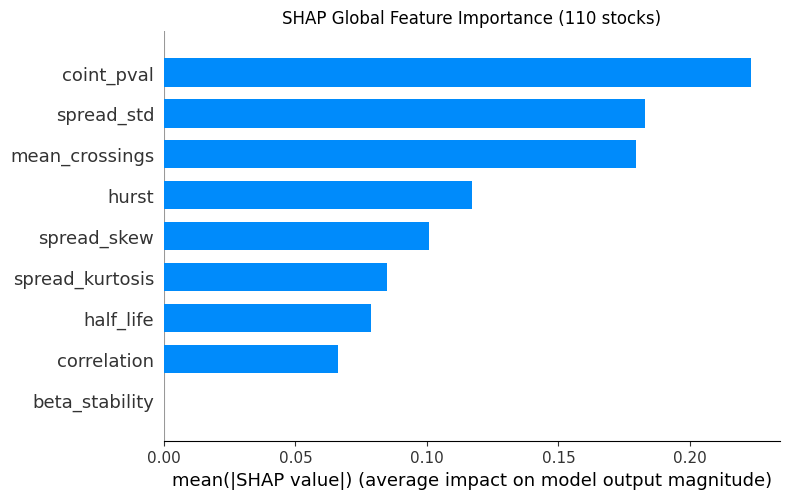


All saved.
Final ML dataset: (23, 19)


In [10]:
from xgboost import XGBRegressor

# Task 6 - Train RF + XGBoost
feature_cols = [
    "coint_pval", "correlation", "spread_std",
    "half_life", "hurst", "spread_skew",
    "spread_kurtosis", "mean_crossings", "beta_stability"
]

X_large = ml_large[feature_cols].copy()
y_large = ml_large["test_sharpe"].copy()

scaler_large = StandardScaler()
X_large_scaled = pd.DataFrame(
    scaler_large.fit_transform(X_large),
    columns=feature_cols)

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_large = RandomForestRegressor(
    n_estimators=200, max_depth=3,
    min_samples_leaf=2, random_state=42)

xgb_large = XGBRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=3, random_state=42, verbosity=0)

rf_cv = cross_val_score(
    rf_large, X_large_scaled, y_large,
    cv=cv, scoring="r2")
xgb_cv = cross_val_score(
    xgb_large, X_large_scaled, y_large,
    cv=cv, scoring="r2")

print("Cross-validation R² on expanded dataset:")
print(f"  RF  mean: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"  XGB mean: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

# train on full
rf_large.fit(X_large_scaled, y_large)
xgb_large.fit(X_large_scaled, y_large)

ml_large["rf_score"]  = rf_large.predict(X_large_scaled)
ml_large["xgb_score"] = xgb_large.predict(X_large_scaled)

# Task 7 - Final comparison
ml_large["pval_score"]  = -ml_large["coint_pval"]
ml_large["hurst_score"] = -ml_large["hurst"]

def top_n_sharpe(df, score_col, n=10):
    top_n = min(n, len(df))
    return round(df.nlargest(top_n, score_col)["test_sharpe"].mean(), 4)

print("\n" + "="*55)
print("FINAL COMPARISON — Average Test Sharpe, Top 10 Pairs")
print("="*55)
print(f"  P-value baseline  : {top_n_sharpe(ml_large, 'pval_score')}")
print(f"  Hurst baseline    : {top_n_sharpe(ml_large, 'hurst_score')}")
print(f"  RF Regressor      : {top_n_sharpe(ml_large, 'rf_score')}")
print(f"  XGBoost           : {top_n_sharpe(ml_large, 'xgb_score')}")
print("="*55)

print("\nTop 10 XGBoost pairs:")
print(ml_large.nlargest(10, "xgb_score")[
    ["ticker_1","ticker_2","xgb_score","test_sharpe"]
].to_string())

# feature importance
print("\nRF top 3 features:")
print(pd.Series(rf_large.feature_importances_,
    index=feature_cols).nlargest(3))
print("\nXGB top 3 features:")
print(pd.Series(xgb_large.feature_importances_,
    index=feature_cols).nlargest(3))

# Task 8 - SHAP
explainer = shap.TreeExplainer(xgb_large)
shap_values = explainer.shap_values(X_large_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rf_imp = pd.Series(rf_large.feature_importances_,
    index=feature_cols).sort_values(ascending=True)
rf_imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("RF Feature Importance (110 stocks)")

xgb_imp = pd.Series(xgb_large.feature_importances_,
    index=feature_cols).sort_values(ascending=True)
xgb_imp.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost Feature Importance (110 stocks)")

plt.tight_layout()
plt.savefig("../data/feature_importance_large.png", dpi=120)
plt.show()

shap.summary_plot(shap_values, X_large_scaled,
    plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (110 stocks)")
plt.tight_layout()
plt.savefig("../data/shap_large.png",
    dpi=120, bbox_inches="tight")
plt.show()

# Task 9 - Save
with open("../data/rf_large.pkl", "wb") as f:
    pickle.dump(rf_large, f)
with open("../data/xgb_large.pkl", "wb") as f:
    pickle.dump(xgb_large, f)
with open("../data/scaler_large.pkl", "wb") as f:
    pickle.dump(scaler_large, f)

ml_large.to_csv("../data/ml_large_ranked.csv", index=False)
print("\nAll saved.")
print(f"Final ML dataset: {ml_large.shape}")